# **Regression**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### **Load pre-split data**

In [2]:
df_train = pd.read_csv('../data/cleaned_train.csv')
df_test = pd.read_csv('../data/cleaned_test.csv')

print(f"Train size: {len(df_train)} | Test size: {len(df_test)}")
df_train.head()

Train size: 15779 | Test size: 3950


,BGGId,Name,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,ComMinPlaytime,ComMaxPlaytime,IsReimplementation,...,Score_cgs,Score_wargames,Score_partygames,Score_childrensgames,Rating,Avg_popularity_log,NumAlternates_log,NumImplementations_log,NumExpansions_log,NumWeightVotes_log
0,166977,Gangster Dice,2015,1.6000,2,4,10.0,20.0,20.0,0,...,0.0,0.0000,0.0,0.0,3,3.355735,0.000000,0.000000,0.693147,1.791759
1,5242,The Game of Y,1953,3.0571,2,2,10.0,20.0,20.0,1,...,0.0,0.0000,0.0,0.0,2,4.317488,1.098612,1.098612,0.000000,3.583519
2,257598,MacGyver: The Escape Room Game,2018,1.5000,1,4,10.0,60.0,60.0,0,...,0.0,0.0000,0.0,0.0,1,5.162879,0.000000,0.000000,0.000000,1.098612
3,69292,Guardians of Graxia,2010,3.0000,1,2,11.0,45.0,45.0,0,...,0.0,0.0003,0.0,0.0,1,5.125946,0.000000,0.000000,0.000000,2.708050
4,231038,Dreamscape,2019,3.1250,1,4,12.0,60.0,90.0,0,...,0.0,0.0000,0.0,0.0,3,6.644657,0.693147,0.000000,1.945910,4.043051


### **Computing correlation**

                    ComAgeRec  GameWeight  ComMaxPlaytime  NumExpansions_log  \
ComAgeRec            1.000000    0.588161        0.547753           0.127967   
GameWeight           0.588161    1.000000        0.651440           0.269123   
ComMaxPlaytime       0.547753    0.651440        1.000000           0.124875   
NumExpansions_log    0.127967    0.269123        0.124875           1.000000   
NumAlternates_log   -0.243674   -0.161969       -0.141659           0.105460   
Avg_popularity_log   0.077288    0.247756        0.130449           0.442382   

                    NumAlternates_log  Avg_popularity_log  
ComAgeRec                   -0.243674            0.077288  
GameWeight                  -0.161969            0.247756  
ComMaxPlaytime              -0.141659            0.130449  
NumExpansions_log            0.105460            0.442382  
NumAlternates_log            1.000000            0.416643  
Avg_popularity_log           0.416643            1.000000  


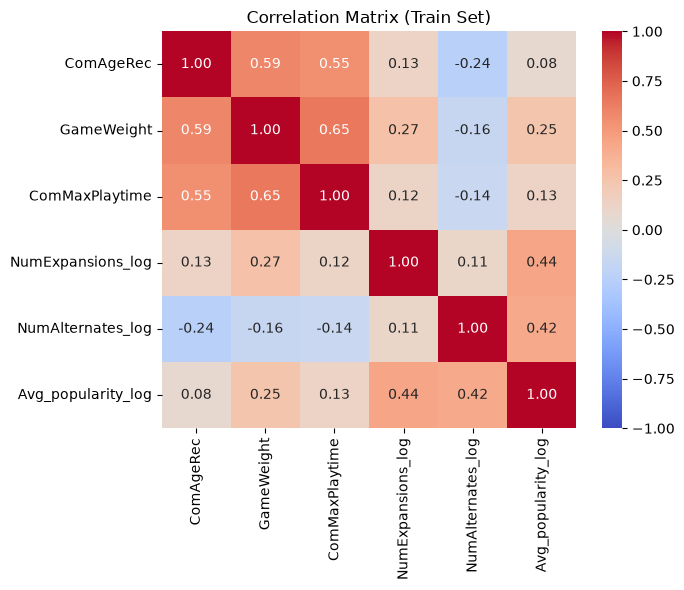

In [3]:
# Compute correlation between ComAgeRec, GameWeight, ComMaxPlaytime and NumExpansions_log
# Computed on the training set only, to avoid letting any test-set structure
# influence exploratory / modeling decisions
correlation_features = ['ComAgeRec', 'GameWeight', 'ComMaxPlaytime', 'NumExpansions_log', 'NumAlternates_log', 'Avg_popularity_log']
correlation_matrix = df_train[correlation_features].corr()
print(correlation_matrix)

plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

### **Variable definition**

In [4]:
# 1. Define target variables
target_w = 'GameWeight'           # For Univariate and Multiple regression
target_p = 'Avg_popularity_log'   # For Multivariate regression (second target)
multivariate_targets = [target_w, target_p]

# 2. Define feature sets
features_uni = ['ComAgeRec']                                          # Univariate: one feature to predict weight
features_multiple = ['ComAgeRec', 'ComMaxPlaytime', 'NumExpansions_log']       # Multiple: 3 features to predict weight
features_multivariate = ['NumAlternates_log', 'ComMaxPlaytime', 'NumExpansions_log']  # Multivariate: predicts weight AND popularity

# 3. Build train/test subsets directly from the pre-split data
# (no train_test_split call here: df_train/df_test are already a held-out
# split produced upstream, and re-splitting a recombined dataset here would
# silently create a different, inconsistent test set from the rest of the project)

# Subsets for Univariate Regression (Target: GameWeight)
X_train_uni = df_train[features_uni]
X_test_uni = df_test[features_uni]
y_train_uni = df_train[target_w]
y_test_uni = df_test[target_w]

# Subsets for Multiple Regression (Target: GameWeight)
X_train_multi = df_train[features_multiple]
X_test_multi = df_test[features_multiple]
y_train_multi = df_train[target_w]
y_test_multi = df_test[target_w]

# Subsets for Multivariate Regression (Targets: GameWeight AND Avg_popularity_log)
# Note: y contains both columns as a matrix
X_train_mvar = df_train[features_multivariate]
X_test_mvar = df_test[features_multivariate]
y_train_mvar = df_train[multivariate_targets]
y_test_mvar = df_test[multivariate_targets]

print("Feature/target subsets ready.")

Feature/target subsets ready.


### **Reusable helper functions**

The five-model x three-task grid search block below was previously duplicated
almost verbatim in three separate cells (univariate, multiple, multivariate). It is
centralized here into `get_model_grid()` (the shared model/hyperparameter definitions)
and two runner functions, one per single-target task, one for the multi-target task.
Ridge, Lasso and KNN are now wrapped in a `StandardScaler` pipeline consistently —
in the original notebook only KNN was scaled, but Ridge/Lasso penalize coefficient
magnitude, so leaving features unscaled biases the regularization strength across
feature units.

In [5]:
def get_model_grid():
    """
    Shared model + hyperparameter-grid definitions, reused by every regression task.
    A model with `param_grid=None` is fit directly (no tuning); otherwise it is
    wrapped in GridSearchCV.
    """
    return {
        "Linear": (
            LinearRegression(),
            None,
        ),
        "Ridge": (
            Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
            {"model__alpha": [0.01, 0.1, 1, 10, 100]},
        ),
        "Lasso": (
            Pipeline([("scaler", StandardScaler()), ("model", Lasso(max_iter=10000))]),
            {"model__alpha": [0.001, 0.01, 0.1, 1, 10]},
        ),
        "Decision Tree": (
            DecisionTreeRegressor(random_state=42),
            {"max_depth": [2, 4, 8, 16, 32]},
        ),
        "K-NN": (
            Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor())]),
            {"knn__n_neighbors": [3, 5, 10, 20, 40, 50, 60]},
        ),
    }


def fit_best_model(estimator, param_grid, X_train, y_train, cv=5):
    """Fit `estimator` directly, or tune it with GridSearchCV if a param_grid is given."""
    if param_grid is None:
        estimator.fit(X_train, y_train)
        return estimator, "N/A"

    search = GridSearchCV(estimator, param_grid, scoring="neg_mean_squared_error", cv=cv)
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_


def evaluate_model(model, X_test, y_test):
    """Compute R2 / MAE / MSE for a single-target regressor."""
    y_pred = model.predict(X_test)
    return {
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
    }


def evaluate_multivariate(model, X_test, y_test, targets):
    """Compute R2 / MAE / MSE separately for each target of a multi-output regressor."""
    predictions = model.predict(X_test)
    scores = []
    for i, target_name in enumerate(targets):
        y_true_target = y_test.iloc[:, i]
        y_pred_target = predictions[:, i]
        scores.append({
            "Target": target_name,
            "R2": r2_score(y_true_target, y_pred_target),
            "MAE": mean_absolute_error(y_true_target, y_pred_target),
            "MSE": mean_squared_error(y_true_target, y_pred_target),
        })
    return scores


def run_single_target_suite(X_train, y_train, X_test, y_test, task_name, cv=5):
    """Fit every model in get_model_grid() on a single target and return a results DataFrame."""
    rows = []
    for name, (estimator, param_grid) in get_model_grid().items():
        best_model, best_params = fit_best_model(estimator, param_grid, X_train, y_train, cv=cv)
        rows.append({
            "Model": name,
            "Task": task_name,
            **evaluate_model(best_model, X_test, y_test),
            "Best Params": str(best_params),
        })
    return pd.DataFrame(rows)


def run_multivariate_suite(X_train, y_train, X_test, y_test, targets, cv=5):
    """Fit every model in get_model_grid() on multiple targets at once and return a results DataFrame."""
    rows = []
    for name, (estimator, param_grid) in get_model_grid().items():
        best_model, best_params = fit_best_model(estimator, param_grid, X_train, y_train, cv=cv)
        for res in evaluate_multivariate(best_model, X_test, y_test, targets):
            rows.append({"Model": name, **res, "Best Params": str(best_params)})
    return pd.DataFrame(rows).sort_values(by=["Target", "R2"], ascending=[True, False])

### **Univariate regression**

In [6]:
results_uni = run_single_target_suite(
    X_train_uni, y_train_uni, X_test_uni, y_test_uni, task_name="Univariate",
)

print("\n--- Hyperparameter Optimization Summary (Univariate) ---")
for _, row in results_uni.iterrows():
    print(f"{row['Model']}: Best Params = {row['Best Params']}")
print("-" * 55)

display(results_uni.sort_values(by="R2", ascending=False))


--- Hyperparameter Optimization Summary (Univariate) ---
Linear: Best Params = N/A
Ridge: Best Params = {'model__alpha': 1}
Lasso: Best Params = {'model__alpha': 0.001}
Decision Tree: Best Params = {'max_depth': 4}
K-NN: Best Params = {'knn__n_neighbors': 60}
-------------------------------------------------------


,Model,Task,R2,MAE,MSE,Best Params
3,Decision Tree,Univariate,0.391138,0.469958,0.366460,{'max_depth': 4}
4,K-NN,Univariate,0.383855,0.472150,0.370844,{'knn__n_neighbors': 60}
0,Linear,Univariate,0.340715,0.486002,0.396808,N/A
1,Ridge,Univariate,0.340714,0.486004,0.396809,{'model__alpha': 1}
2,Lasso,Univariate,0.340679,0.486061,0.396830,{'model__alpha': 0.001}


### **Multiple regression**

In [7]:
results_multi = run_single_target_suite(
    X_train_multi, y_train_multi, X_test_multi, y_test_multi, task_name="Multiple",
)

print("\n--- Hyperparameter Optimization Summary (Multiple Regression) ---")
for _, row in results_multi.iterrows():
    print(f"{row['Model']}: Best Params = {row['Best Params']}")
print("-" * 60)

display(results_multi.sort_values(by="R2", ascending=False))


--- Hyperparameter Optimization Summary (Multiple Regression) ---
Linear: Best Params = N/A
Ridge: Best Params = {'model__alpha': 10}
Lasso: Best Params = {'model__alpha': 0.001}
Decision Tree: Best Params = {'max_depth': 8}
K-NN: Best Params = {'knn__n_neighbors': 50}
------------------------------------------------------------


,Model,Task,R2,MAE,MSE,Best Params
4,K-NN,Multiple,0.585126,0.386652,0.249703,{'knn__n_neighbors': 50}
3,Decision Tree,Multiple,0.572421,0.389276,0.257350,{'max_depth': 8}
0,Linear,Multiple,0.539207,0.411888,0.277341,N/A
1,Ridge,Multiple,0.539189,0.411906,0.277352,{'model__alpha': 10}
2,Lasso,Multiple,0.539085,0.412026,0.277414,{'model__alpha': 0.001}


### **Multivariate regression**

In [8]:
results_mvar_separated = run_multivariate_suite(
    X_train_mvar, y_train_mvar, X_test_mvar, y_test_mvar, targets=multivariate_targets,
)

display(results_mvar_separated)

,Model,Target,R2,MAE,MSE,Best Params
9,K-NN,Avg_popularity_log,0.355317,0.850221,1.160881,{'knn__n_neighbors': 50}
7,Decision Tree,Avg_popularity_log,0.342603,0.855725,1.183775,{'max_depth': 8}
3,Ridge,Avg_popularity_log,0.332429,0.871484,1.202096,{'model__alpha': 10}
1,Linear,Avg_popularity_log,0.332425,0.871463,1.202102,N/A
5,Lasso,Avg_popularity_log,0.332421,0.871530,1.202109,{'model__alpha': 0.001}
8,K-NN,GameWeight,0.521070,0.419268,0.288257,{'knn__n_neighbors': 50}
6,Decision Tree,GameWeight,0.520148,0.420389,0.288812,{'max_depth': 8}
0,Linear,GameWeight,0.476414,0.446929,0.315135,N/A
2,Ridge,GameWeight,0.476395,0.446955,0.315146,{'model__alpha': 10}
4,Lasso,GameWeight,0.476343,0.447071,0.315177,{'model__alpha': 0.001}


### **Model comparison across tasks**

Univariate and Multiple regression share the same target (`GameWeight`), so their results can be combined into a single ranked overview.

In [9]:
results_overview = pd.concat([results_uni, results_multi], ignore_index=True)
results_overview = results_overview.sort_values(by="R2", ascending=False)
display(results_overview)

,Model,Task,R2,MAE,MSE,Best Params
9,K-NN,Multiple,0.585126,0.386652,0.249703,{'knn__n_neighbors': 50}
8,Decision Tree,Multiple,0.572421,0.389276,0.257350,{'max_depth': 8}
5,Linear,Multiple,0.539207,0.411888,0.277341,N/A
6,Ridge,Multiple,0.539189,0.411906,0.277352,{'model__alpha': 10}
7,Lasso,Multiple,0.539085,0.412026,0.277414,{'model__alpha': 0.001}
3,Decision Tree,Univariate,0.391138,0.469958,0.366460,{'max_depth': 4}
4,K-NN,Univariate,0.383855,0.472150,0.370844,{'knn__n_neighbors': 60}
0,Linear,Univariate,0.340715,0.486002,0.396808,N/A
1,Ridge,Univariate,0.340714,0.486004,0.396809,{'model__alpha': 1}
2,Lasso,Univariate,0.340679,0.486061,0.396830,{'model__alpha': 0.001}
